In [60]:
from statsbombpy import sb
import pandas as pd
from mplsoccer import Pitch, Sbopen
import matplotlib.pyplot as plt
comps = sb.competitions()
# comps["competition_name"].unique()
comps[comps["competition_name"]=="FIFA World Cup"]

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
29,43,106,International,FIFA World Cup,male,False,True,2022,2024-12-16T10:15:11.055845,2024-12-16T10:21:13.710934,2024-12-16T10:21:13.710934,2024-12-16T10:15:11.055845
30,43,3,International,FIFA World Cup,male,False,True,2018,2024-06-12T07:38:19.345758,2021-06-13T16:17:31.694,None,2024-06-12T07:38:19.345758
31,43,55,International,FIFA World Cup,male,False,True,1990,2023-06-28T10:58:20.137929,2021-06-12T16:17:31.694,None,2023-06-28T10:58:20.137929
32,43,54,International,FIFA World Cup,male,False,True,1986,2023-12-26T22:34:04.263530,2021-06-13T16:17:31.694,None,2023-12-26T22:34:04.263530
33,43,51,International,FIFA World Cup,male,False,True,1974,2024-02-13T02:52:29.582599,2021-06-13T16:17:31.694,None,2024-02-13T02:52:29.582599
34,43,272,International,FIFA World Cup,male,False,True,1970,2024-02-13T14:23:06.735299,None,None,2024-02-13T14:23:06.735299
35,43,270,International,FIFA World Cup,male,False,True,1962,2023-06-26T10:38:00.323984,None,None,2023-06-26T10:38:00.323984
36,43,269,International,FIFA World Cup,male,False,True,1958,2024-02-13T14:22:08.222297,None,None,2024-02-13T14:22:08.222297


In [61]:
matches=sb.matches(competition_id=43,season_id=106)
matches[matches['home_team']=='Belgium']

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,...,home_manager_country_name,away_manager_id,away_manager_name,away_manager_nickname,away_manager_dob,away_manager_country_id,away_manager_country_name,data_version,shot_fidelity_version,xy_fidelity_version
32,3857283,2022-11-27,15:00:00.000,0,2,available,available,2023-02-28T21:26:37.636261,2023-06-21T18:29:02.259940,2,...,Spain,1000518,Walid Regragui,None,1975-09-23,154,Morocco,1.1.0,2,2
58,3857268,2022-11-23,21:00:00.000,1,0,available,available,2023-08-12T16:44:27.619465,2023-08-12T16:48:09.197442,1,...,Spain,4435,John Herdman,None,1975-07-19,68,England,1.1.0,2,2


In [62]:
events = sb.events(match_id=3857283)
parser = Sbopen()
df, related, freeze, tactics = parser.event(3857283)
df.columns

Index(['id', 'index', 'period', 'timestamp', 'minute', 'second', 'possession',
       'duration', 'match_id', 'type_id', 'type_name', 'possession_team_id',
       'possession_team_name', 'play_pattern_id', 'play_pattern_name',
       'team_id', 'team_name', 'tactics_formation', 'player_id', 'player_name',
       'position_id', 'position_name', 'pass_recipient_id',
       'pass_recipient_name', 'pass_length', 'pass_angle', 'pass_height_id',
       'pass_height_name', 'end_x', 'end_y', 'body_part_id', 'body_part_name',
       'sub_type_id', 'sub_type_name', 'x', 'y', 'under_pressure',
       'outcome_id', 'outcome_name', 'ball_recovery_recovery_failure',
       'counterpress', 'pass_cross', 'off_camera', 'out',
       'pass_assisted_shot_id', 'pass_shot_assist', 'shot_statsbomb_xg',
       'end_z', 'shot_key_pass_id', 'technique_id', 'technique_name',
       'shot_first_time', 'goalkeeper_position_id', 'goalkeeper_position_name',
       'pass_switch', 'aerial_won', 'dribble_overrun',
   

In [63]:
df = df[df['team_name']=="Belgium"]
df['type_name'].unique()

array(['Starting XI', 'Half Start', 'Pass', 'Ball Receipt', 'Carry',
       'Ball Recovery', 'Dispossessed', 'Pressure', 'Dribbled Past',
       'Foul Won', 'Dribble', 'Miscontrol', 'Injury Stoppage',
       'Clearance', 'Duel', 'Shot', 'Shield', 'Block', '50/50',
       'Foul Committed', 'Interception', 'Goal Keeper', 'Offside',
       'Half End', 'Substitution', 'Tactical Shift'], dtype=object)

In [64]:
passes = df[df['type_name']=='Pass']
passes.columns

Index(['id', 'index', 'period', 'timestamp', 'minute', 'second', 'possession',
       'duration', 'match_id', 'type_id', 'type_name', 'possession_team_id',
       'possession_team_name', 'play_pattern_id', 'play_pattern_name',
       'team_id', 'team_name', 'tactics_formation', 'player_id', 'player_name',
       'position_id', 'position_name', 'pass_recipient_id',
       'pass_recipient_name', 'pass_length', 'pass_angle', 'pass_height_id',
       'pass_height_name', 'end_x', 'end_y', 'body_part_id', 'body_part_name',
       'sub_type_id', 'sub_type_name', 'x', 'y', 'under_pressure',
       'outcome_id', 'outcome_name', 'ball_recovery_recovery_failure',
       'counterpress', 'pass_cross', 'off_camera', 'out',
       'pass_assisted_shot_id', 'pass_shot_assist', 'shot_statsbomb_xg',
       'end_z', 'shot_key_pass_id', 'technique_id', 'technique_name',
       'shot_first_time', 'goalkeeper_position_id', 'goalkeeper_position_name',
       'pass_switch', 'aerial_won', 'dribble_overrun',
   

In [65]:
passes = passes[['id','minute','player_id','player_name','x','y','end_x', 'end_y','pass_recipient_id','pass_recipient_name','outcome_id','outcome_name']]

In [66]:
successful=passes[passes['outcome_name'].isnull()]

In [67]:
successful = successful[successful['minute']<46]
successful

,id,minute,player_id,player_name,x,y,end_x,end_y,pass_recipient_id,pass_recipient_name,outcome_id,outcome_name
4,f8d0bd4d-b769-44b6-9114-9a4fae7ee547,0,3457.0,Michy Batshuayi Tunga,60.0,40.0,52.9,36.0,5642.0,Axel Witsel,NaN,NaN
7,8eced6a4-ea03-4e03-b90f-ff09ff38996f,0,5642.0,Axel Witsel,49.9,37.1,32.6,54.2,20005.0,Toby Alderweireld,NaN,NaN
10,3c96e345-701d-4260-b2a5-6203f1cceceb,0,20005.0,Toby Alderweireld,32.6,54.2,43.4,52.2,48347.0,Amadou Onana,NaN,NaN
13,4228680a-ce97-49c0-8cfd-a13fbd7c0068,0,48347.0,Amadou Onana,43.4,52.2,30.7,56.2,20005.0,Toby Alderweireld,NaN,NaN
16,1f2153bb-0cdb-4ae1-8f1c-df5774b28086,0,20005.0,Toby Alderweireld,30.7,56.2,22.8,28.2,3077.0,Jan Vertonghen,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1751,6a797030-aff0-487e-b3c0-a6428a09c1e0,44,3089.0,Kevin De Bruyne,50.3,50.9,45.2,43.8,20005.0,Toby Alderweireld,NaN,NaN
1759,edab5554-4459-4c49-837a-11b1d33fb00c,44,3089.0,Kevin De Bruyne,69.0,56.0,82.1,52.9,3621.0,Eden Hazard,NaN,NaN
1819,fd3798a8-97a9-4550-b66e-df7f06701373,45,3077.0,Jan Vertonghen,30.8,16.2,4.1,35.2,3509.0,Thibaut Courtois,NaN,NaN
1822,40228275-7369-4096-a82b-e67ad5f2bd1a,45,3509.0,Thibaut Courtois,4.1,35.0,15.0,7.0,3077.0,Jan Vertonghen,NaN,NaN


In [68]:
df_lineup = parser.lineup(3857283)
jersey_data=df_lineup[['player_id','jersey_number']]
jersey_data

,player_id,jersey_number
0,2954,8
1,3077,5
2,3089,7
3,3176,15
4,3289,9
5,3457,23
6,3509,1
7,3539,12
8,3621,10
9,5630,14


In [69]:
successful= pd.merge(successful,jersey_data,on='player_id')
successful.rename(columns={'jersey_number':'passer'},inplace=True)
successful

,id,minute,player_id,player_name,x,y,end_x,end_y,pass_recipient_id,pass_recipient_name,outcome_id,outcome_name,passer
0,f8d0bd4d-b769-44b6-9114-9a4fae7ee547,0,3457.0,Michy Batshuayi Tunga,60.0,40.0,52.9,36.0,5642.0,Axel Witsel,NaN,NaN,23
1,8eced6a4-ea03-4e03-b90f-ff09ff38996f,0,5642.0,Axel Witsel,49.9,37.1,32.6,54.2,20005.0,Toby Alderweireld,NaN,NaN,6
2,3c96e345-701d-4260-b2a5-6203f1cceceb,0,20005.0,Toby Alderweireld,32.6,54.2,43.4,52.2,48347.0,Amadou Onana,NaN,NaN,2
3,4228680a-ce97-49c0-8cfd-a13fbd7c0068,0,48347.0,Amadou Onana,43.4,52.2,30.7,56.2,20005.0,Toby Alderweireld,NaN,NaN,18
4,1f2153bb-0cdb-4ae1-8f1c-df5774b28086,0,20005.0,Toby Alderweireld,30.7,56.2,22.8,28.2,3077.0,Jan Vertonghen,NaN,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,6a797030-aff0-487e-b3c0-a6428a09c1e0,44,3089.0,Kevin De Bruyne,50.3,50.9,45.2,43.8,20005.0,Toby Alderweireld,NaN,NaN,7
315,edab5554-4459-4c49-837a-11b1d33fb00c,44,3089.0,Kevin De Bruyne,69.0,56.0,82.1,52.9,3621.0,Eden Hazard,NaN,NaN,7
316,fd3798a8-97a9-4550-b66e-df7f06701373,45,3077.0,Jan Vertonghen,30.8,16.2,4.1,35.2,3509.0,Thibaut Courtois,NaN,NaN,5
317,40228275-7369-4096-a82b-e67ad5f2bd1a,45,3509.0,Thibaut Courtois,4.1,35.0,15.0,7.0,3077.0,Jan Vertonghen,NaN,NaN,1


In [71]:
jersey_data.rename(columns={'player_id':'pass_recipient_id'},inplace=True)
successful = pd.merge(successful,jersey_data, on='pass_recipient_id')
successful.rename(columns={'jersey_number':'recipient'},inplace=True)
successful

C:\Users\HP\AppData\Local\Temp\ipykernel_23852\1718113474.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  jersey_data.rename(columns={'player_id':'pass_recipient_id'},inplace=True)


,id,minute,player_id,player_name,x,y,end_x,end_y,pass_recipient_id,pass_recipient_name,outcome_id,outcome_name,passer,recipient
0,f8d0bd4d-b769-44b6-9114-9a4fae7ee547,0,3457.0,Michy Batshuayi Tunga,60.0,40.0,52.9,36.0,5642.0,Axel Witsel,NaN,NaN,23,6
1,8eced6a4-ea03-4e03-b90f-ff09ff38996f,0,5642.0,Axel Witsel,49.9,37.1,32.6,54.2,20005.0,Toby Alderweireld,NaN,NaN,6,2
2,3c96e345-701d-4260-b2a5-6203f1cceceb,0,20005.0,Toby Alderweireld,32.6,54.2,43.4,52.2,48347.0,Amadou Onana,NaN,NaN,2,18
3,4228680a-ce97-49c0-8cfd-a13fbd7c0068,0,48347.0,Amadou Onana,43.4,52.2,30.7,56.2,20005.0,Toby Alderweireld,NaN,NaN,18,2
4,1f2153bb-0cdb-4ae1-8f1c-df5774b28086,0,20005.0,Toby Alderweireld,30.7,56.2,22.8,28.2,3077.0,Jan Vertonghen,NaN,NaN,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,6a797030-aff0-487e-b3c0-a6428a09c1e0,44,3089.0,Kevin De Bruyne,50.3,50.9,45.2,43.8,20005.0,Toby Alderweireld,NaN,NaN,7,2
315,edab5554-4459-4c49-837a-11b1d33fb00c,44,3089.0,Kevin De Bruyne,69.0,56.0,82.1,52.9,3621.0,Eden Hazard,NaN,NaN,7,10
316,fd3798a8-97a9-4550-b66e-df7f06701373,45,3077.0,Jan Vertonghen,30.8,16.2,4.1,35.2,3509.0,Thibaut Courtois,NaN,NaN,5,1
317,40228275-7369-4096-a82b-e67ad5f2bd1a,45,3509.0,Thibaut Courtois,4.1,35.0,15.0,7.0,3077.0,Jan Vertonghen,NaN,NaN,1,5


In [72]:
average_locations= successful.groupby('passer').agg({'x':['mean'],'y':['mean','count']})
average_locations.columns = ['x','y','count']
average_locations

,x,y,count
passer,,,
1,11.981250,40.968750,16
2,42.882759,54.860345,58
5,38.243548,26.551613,62
6,56.505556,29.672222,36
7,66.928571,43.250000,14
10,75.877778,27.388889,18
15,59.841379,70.713793,29
16,81.126316,7.163158,19
18,61.089286,37.982143,28


In [73]:
pass_between = successful.groupby(['passer','recipient']).id.count().reset_index()
pass_between.rename({'id':'pass_count'},axis='columns',inplace=True)
pass_between

,passer,recipient,pass_count
0,1,2,3
1,1,5,9
2,1,6,1
3,1,7,1
4,1,21,2
...,...,...,...
69,21,18,2
70,21,23,1
71,23,2,1
72,23,6,1


In [74]:
pass_between= pd.merge(pass_between, average_locations, on='passer')
pass_between

,passer,recipient,pass_count,x,y,count
0,1,2,3,11.981250,40.968750,16
1,1,5,9,11.981250,40.968750,16
2,1,6,1,11.981250,40.968750,16
3,1,7,1,11.981250,40.968750,16
4,1,21,2,11.981250,40.968750,16
...,...,...,...,...,...,...
69,21,18,2,53.577143,9.902857,35
70,21,23,1,53.577143,9.902857,35
71,23,2,1,67.125000,51.000000,4
72,23,6,1,67.125000,51.000000,4


In [75]:
average_locations=average_locations.rename_axis('recipient')
pass_between= pd.merge(pass_between, average_locations, on='recipient',suffixes=['','_end'])
pass_between

,passer,recipient,pass_count,x,y,count,x_end,y_end,count_end
0,1,2,3,11.981250,40.968750,16,42.882759,54.860345,58
1,1,5,9,11.981250,40.968750,16,38.243548,26.551613,62
2,1,6,1,11.981250,40.968750,16,56.505556,29.672222,36
3,1,7,1,11.981250,40.968750,16,66.928571,43.250000,14
4,1,21,2,11.981250,40.968750,16,53.577143,9.902857,35
...,...,...,...,...,...,...,...,...,...
69,21,18,2,53.577143,9.902857,35,61.089286,37.982143,28
70,21,23,1,53.577143,9.902857,35,67.125000,51.000000,4
71,23,2,1,67.125000,51.000000,4,42.882759,54.860345,58
72,23,6,1,67.125000,51.000000,4,56.505556,29.672222,36


In [76]:
pass_between =pass_between[pass_between['pass_count']>3]
pass_between.drop_duplicates()
pass_between

,passer,recipient,pass_count,x,y,count,x_end,y_end,count_end
1,1,5,9,11.981250,40.968750,16,38.243548,26.551613,62
6,2,5,24,42.882759,54.860345,58,38.243548,26.551613,62
7,2,6,4,42.882759,54.860345,58,56.505556,29.672222,36
10,2,15,17,42.882759,54.860345,58,59.841379,70.713793,29
11,2,18,7,42.882759,54.860345,58,61.089286,37.982143,28
12,5,1,4,38.243548,26.551613,62,11.981250,40.968750,16
13,5,2,26,38.243548,26.551613,62,42.882759,54.860345,58
14,5,6,8,38.243548,26.551613,62,56.505556,29.672222,36
18,5,18,4,38.243548,26.551613,62,61.089286,37.982143,28
19,5,21,15,38.243548,26.551613,62,53.577143,9.902857,35


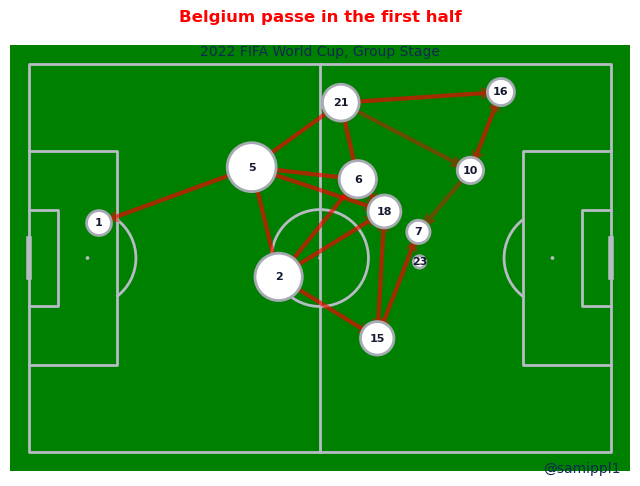

In [77]:
pitch = Pitch(pitch_color='green', line_color='#B6BBC4')
# Set the figure size
fig, ax = pitch.draw(figsize=(8, 6), constrained_layout=True, tight_layout=False)

# Set the face color of the figure
fig.set_facecolor('#FFFFFF')

# Draw arrows and nodes
arrows = pitch.arrows(1.2 * pass_between.x, 0.8 * pass_between.y, 1.2 * pass_between.x_end, 0.8 * pass_between.y_end, ax=ax,color='red', alpha=0.4,width=3)
# arrows = pass_between.apply(create_arrow, axis=1)
# for arrow in arrows:
#     ax.add_patch(arrow)
                 
nodes = pitch.scatter(1.2 * average_locations.x, 0.8 * average_locations.y, s=20*average_locations['count'].values, color='white', edgecolors='#a6aab3', linewidth=2, alpha=1, zorder=1, ax=ax)

                 
# Annotate average_locations
for index, row in average_locations.iterrows():
    pitch.annotate(index, xy=(1.2 * row.x, 0.8 * row.y), c='#161A30',fontweight='bold', va='center', ha='center', size=8, ax=ax)

# Add the endnote
ax.text(114, 85, '@samippl1', color='#0E2954', va='bottom', ha='center', fontsize=10)

# Add the title
ax.set_title('Belgium passe in the first half', color='red', va='center', ha='center', fontsize=12,fontweight='bold',pad=20,loc='center')
ax.annotate('2022 FIFA World Cup, Group Stage', xy=(0.5, 1), xytext=(0, 0),
             xycoords='axes fraction', textcoords='offset points',
             fontsize=10, color='#0E2954', va='top', ha='center')


plt.show()